# 🌟 Exercise 1 : Small Quizz


1. What is the key difference between traditional machine learning and deep learning?
- Deep learning automatically learns hierarchical feature representations from raw data, while traditional machine learning relies on manual feature engineering.

2. How do artificial neural networks (ANNs) mimic the human brain?
- ANNs mimic the brain's network of neurons by using interconnected nodes (artificial neurons) that transmit and process signals via weighted connections.

3. Why does deep learning perform better on large datasets compared to traditional machine learning?
- Deep learning performs better on large datasets because its complex, multi-layered architectures can uncover intricate patterns that scale with data volume.

4. What are some challenges of deep learning, and how can they be addressed?
- Challenges include high computational cost, large data requirements, and "black box" nature, addressed with better hardware, data augmentation, and explainable AI techniques.

5. What is feature engineering, and why is it not needed in deep learning?
- Feature engineering is manually creating input features; deep learning eliminates this need by automatically learning optimal features from raw data.

6. What role do hidden layers play in a deep learning model?
- Hidden layers progressively transform input data into higher-level, abstract representations essential for learning complex patterns.

7. In an artificial neural network (ANN), what is the function of an activation function?
- An activation function introduces non-linearity into a neuron's output, enabling the network to learn and model complex, non-linear relationships.

# 🌟 Exercise 2 : Building a Simple Perceptron Decision System


In [ ]:
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s >threshold  else 0

In [3]:
def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute s = 0.6*Temperature + 0.4*Rain + Bias."""
    # To-Do: replace 'pass' with the formula using W_TEMP, W_RAIN, BIAS
    return W_TEMP * temperature_f + W_RAIN * rain01 + BIAS

# To-Do: compute decisions for the two cases and print them
case1 = (70, 0)  # Temperature=70, Rain=0
case2 = (50, 1)  # Temperature=50, Rain=1

s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)
y1 = step_activation(s1)
y2 = step_activation(s2)

print({"case1": {"sum": s1, "decision": y1}, "case2": {"sum": s2, "decision": y2}})


{'case1': {'sum': 44.0, 'decision': 1}, 'case2': {'sum': 32.4, 'decision': 1}}


From our results, our perceptron suggest going outside because the weighted sum for our two cases are above the threshold (>20), and as our activation function is the Step Function that's if the number is above a certain value (threshold), it says 'yes', Otherwise, it says 'no', so it suggest going outside.

# 🌟 Exercise 3 : Building a Simple Neural Network with TensorFlow/Keras

1. Import TensorFlow and other necessary modules such as layers, models, and utility functions from tensorflow.keras

In [4]:
import tensorflow as tf
from tensorflow import keras

2. Load the MNIST Dataset

In [5]:
(x_train_data, y_train_data), (x_val_data, y_val_data) = keras.datasets.fashion_mnist.load_data()

4422102/4422102 [==============================] - 1s 0us/step


3. Normalize the Data by scaling the pixel values of the images to the range [0, 1] by dividing by 255.0.

In [6]:
def preprocessing_function(x_new, y_new):
  x_new = tf.cast(x_new, tf.float32) / 255.0  # Normalize pixel values
  y_new = tf.cast(y_new, tf.int64)            # Convert labels to integers
  return x_new, y_new

4. One-Hot Encode the Labels by converting the digit labels (0–9) into one-hot encoded vectors.

In [7]:
def func_creating_dataset(xs_data, ys_data, num_classes=10):
  ys_data = tf.one_hot(ys_data, depth=num_classes)  # One-hot encode labels
  return tf.data.Dataset.from_tensor_slices((xs_data, ys_data)) \
    .map(preprocessing_function) \
    .shuffle(buffer_size=1000) \
    .batch(32)

In [8]:
# Create the training and validation datasets using func_creating_dataset
dataset_training = func_creating_dataset(x_train_data, y_train_data) # Creating the training dataset
dataset_val = func_creating_dataset(x_val_data, y_val_data)       # Creating the validation dataset

5. To build the Neural Network Model, create a sequential model with the following architecture:

- A Flatten layer to convert each 28x28 image into a 1D vector.
- A Dense hidden layer with 128 neurons and ReLU activation.
- An output Dense layer with 10 neurons and softmax activation (for the 10 classes).

In [9]:
My_model = keras.Sequential([
    keras.layers.Reshape(target_shape=(28 * 28,), input_shape=(28, 28)),  # Flatten the input
    keras.layers.Dense(units=128, activation='relu'),                    # Hidden layer: A layer with 128 neurons and the ReLU activation function.
    keras.layers.Dense(units=10, activation='softmax')                   # Output layer :  Outputs 10 probabilities (one for each class).
])

6. Compile the model with the following settings:

- Optimizer: ‘adam’
- Loss function: ‘categorical_crossentropy’
- Metrics: [‘accuracy’]

In [10]:
My_model.compile(optimizer='adam',
              loss=tf.losses.CategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

7. Train the Model and Evaluate it on the test dataset.

In [11]:
history = My_model.fit(
    dataset_training.repeat(),
    epochs=10,
    steps_per_epoch=500,
    validation_data=dataset_val.repeat(),
    validation_steps=2
)

Make_predictions = My_model.predict(dataset_val)
print(Make_predictions)

test_loss, test_accuracy = My_model.evaluate(dataset_val)
print(f"Test Accuracy: {test_accuracy:.2f}")

Epoch 1/10


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\keras\src\backend.py:5562: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


500/500 [==============================] - 5s 6ms/step - loss: 0.6363 - accuracy: 0.7761 - val_loss: 0.4567 - val_accuracy: 0.8125
Epoch 2/10
500/500 [==============================] - 4s 7ms/step - loss: 0.4897 - accuracy: 0.8264 - val_loss: 0.6238 - val_accuracy: 0.7656
Epoch 3/10
500/500 [==============================] - 4s 7ms/step - loss: 0.4454 - accuracy: 0.8459 - val_loss: 0.3679 - val_accuracy: 0.8125
Epoch 4/10
500/500 [==============================] - 4s 8ms/step - loss: 0.4186 - accuracy: 0.8501 - val_loss: 0.6212 - val_accuracy: 0.7500
Epoch 5/10
500/500 [==============================] - 4s 8ms/step - loss: 0.3967 - accuracy: 0.8540 - val_loss: 0.3890 - val_accuracy: 0.8906
Epoch 6/10
500/500 [==============================] - 4s 8ms/step - loss: 0.3752 - accuracy: 0.8655 - val_loss: 0.2772 - val_accuracy: 0.8750
Epoch 7/10
500/500 [==============================] - 4s 9ms/step - loss: 0.3709 - accuracy: 0.8652 - val_loss: 0.2468 - val_accuracy: 0.8906
Epoch 8/10
500/50

# 🌟 Exercise 4 : Forward Propagation Calculation

In [12]:
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# compute z = x1*w1 + x2*w2 + b
z = x1*w1 + x2*w2 + b

#apply ReLU
y = max(0, z)

print({"z": z, "prediction": y})

{'z': 51002.1, 'prediction': 51002.1}


the predicted house price is 51002.1

# 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

In [13]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)

Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


Gradient descent figures out how to tweak each weight to make predictions better by using math to find which way is "downhill" toward less error, then nudges the weights bit by bit in that direction.

In [21]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.8, 0.8])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)

Initial Prediction: 77.2
Loss: 30.419999999999977
Updated Weights: [1.112 7.04 ]
Updated Bias: 10.078


# 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

1/1 [==============================] - 0s 140ms/step


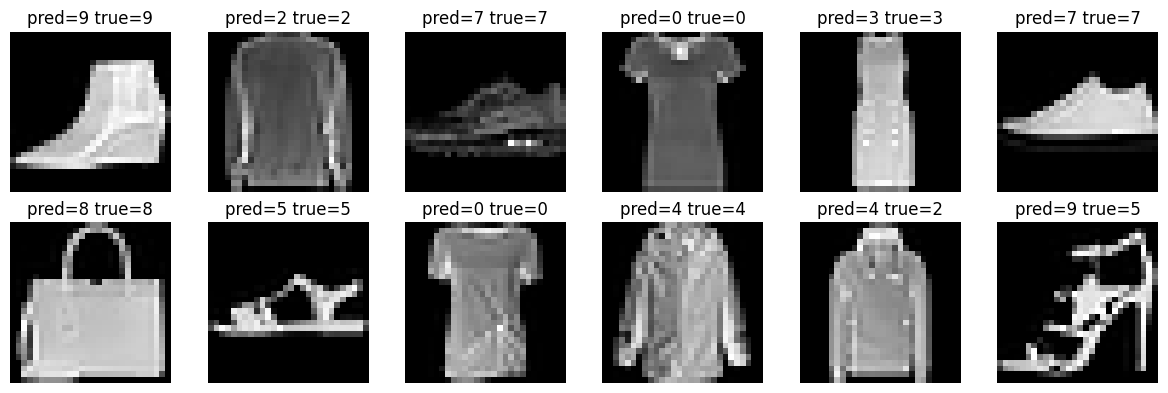

In [23]:
# To-Do: visualize a few predictions with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Ensure we have the model and x_test, y_test from Exercise 3
# To-Do: select N samples from x_test by using np.random.choice
idx = np.random.choice(len(x_val_data), size=12, replace=False)
x_vis = x_val_data[idx]
y_true = y_val_data[idx]

# To-Do: get predictions
y_prob = My_model.predict(x_vis)
y_pred = np.argmax(y_prob, axis=1)

#plotting
cols = 6
rows = int(np.ceil(len(idx)/cols))
plt.figure(figsize=(12, 2*rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_val_data[k], cmap="gray")
    plt.title(f"pred={y_pred[i-1]} true={y_true[i-1]}" )
    plt.axis("off")
plt.tight_layout()
plt.show()